In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

from src.processing import load_and_clean_data
from src.features import generate_features
from src.features_rv import generate_rv_features
from src.pooling import pool_boj_data
from src.pooling_curve import pool_curve_data
from src.pooling_butterfly import pool_butterfly_data
from src.modeling import walk_forward_validation, summarize_ic

START_DATE = '2024-01-01'
COLORS = {'Outright': '#1f77b4', 'Curve': '#2ca02c', 'Butterfly': '#ff7f0e'}
MODELS  = ['Outright', 'Curve', 'Butterfly']

# 各モデルで CS IC に使う Meeting_Index の範囲
CS_INDICES = {
    'Outright':  set(range(1, 9)),   # M1-M8
    'Curve':     set(range(1, 8)),   # C1-C7
    'Butterfly': set(range(2, 8)),   # B2-B7
}

# 表示用ラベル: Meeting_Index → 銘柄名
INST_LABELS = {
    'Outright':  {i: f'M{i}' for i in range(1, 9)},
    'Curve':     {i: f'C{i}\n(M{i}-M{i+1})' for i in range(1, 8)},
    'Butterfly': {i: f'B{i}\n(2M{i}-M{i-1}-M{i+1})' for i in range(2, 8)},
}
INST_SHORT = {
    'Outright':  {i: f'M{i}' for i in range(1, 9)},
    'Curve':     {i: f'C{i}' for i in range(1, 8)},
    'Butterfly': {i: f'B{i}' for i in range(2, 8)},
}

In [2]:
# ── データ読み込み・プーリング ──────────────────────────────────
print('Loading data...')
df_raw = load_and_clean_data('../data/BOJ_data.xlsx', '../data/BOJ_meeting_history.csv')

print('Generating features...')
df_feat_out = generate_features(df_raw)
df_feat_rv  = generate_rv_features(df_raw)

print('Pooling...')
df_out   = pool_boj_data(df_feat_out)
df_curve = pool_curve_data(df_feat_rv)
df_fly   = pool_butterfly_data(df_feat_rv)

print(f'Shapes  Outright={df_out.shape}  Curve={df_curve.shape}  Butterfly={df_fly.shape}')

Loading data...


Generating features...
Pooling...


Shapes  Outright=(50639, 53)  Curve=(32571, 35)  Butterfly=(27918, 36)


In [3]:
# ── Walk-Forward Validation（全モデル・全ホライズン）─────────────
pool_map = {'Outright': df_out, 'Curve': df_curve, 'Butterfly': df_fly}

res = {}
for model, df_pool in pool_map.items():
    for h in ['3d', '5d']:
        key = f'{model}_{h}'
        print(f'Running {key}...')
        res[key] = walk_forward_validation(df_pool, f'Target_{h}_norm', START_DATE)

# Days_to_MPM を結果に結合（(Date, Meeting_Index) で一意）
for model, df_pool in pool_map.items():
    days_map = df_pool[['Date', 'Meeting_Index', 'Days_to_MPM']].drop_duplicates()
    for h in ['3d', '5d']:
        key = f'{model}_{h}'
        res[key] = res[key].merge(days_map, on=['Date', 'Meeting_Index'], how='left')

# 全体サマリー
print('\n=== IC Summary ===')
for model in MODELS:
    for h in ['3d', '5d']:
        key = f'{model}_{h}'
        r   = res[key]
        ic  = summarize_ic(r, instrument_indices=CS_INDICES[model])
        print(f'{model:10s} {h}  global={ic["ic_all"]:+.3f}  cs={ic["cs_ic"]:+.3f}  '
              f'ts={ic["ts_ic"]:+.3f}  train={ic["train_ic"]:+.3f}  gap={ic["gap"]:+.3f}')

Running Outright_3d...


Running Outright_5d...


Running Curve_3d...


Running Curve_5d...


Running Butterfly_3d...


Running Butterfly_5d...



=== IC Summary ===
Outright   3d  global=+0.227  cs=-0.005  ts=+0.229  train=+0.519  gap=+0.292
Outright   5d  global=+0.228  cs=+0.074  ts=+0.234  train=+0.564  gap=+0.336
Curve      3d  global=+0.222  cs=+0.202  ts=+0.224  train=+0.469  gap=+0.246


Curve      5d  global=+0.278  cs=+0.249  ts=+0.286  train=+0.525  gap=+0.248
Butterfly  3d  global=+0.373  cs=+0.304  ts=+0.376  train=+0.521  gap=+0.148
Butterfly  5d  global=+0.418  cs=+0.346  ts=+0.423  train=+0.573  gap=+0.154


In [4]:
# ── ヘルパー関数 ───────────────────────────────────────────────

def fold_global_ic(results):
    """フォールドごとの Global IC"""
    out = {}
    for fold, grp in results.groupby('Fold'):
        if len(grp) >= 5:
            ic, _ = spearmanr(grp['Actual'], grp['Pred'])
            out[int(fold)] = float(ic) if not np.isnan(ic) else np.nan
    return out

def fold_cs_ic(results, instrument_indices, min_per_date=3):
    """フォールドごとの CS IC（日付内ランク相関の平均）"""
    filtered = results[results['Meeting_Index'].isin(instrument_indices)].copy()
    out = {}
    for fold, fold_grp in filtered.groupby('Fold'):
        date_ics = []
        for _, dgrp in fold_grp.groupby('Date'):
            if len(dgrp) >= min_per_date:
                ic, _ = spearmanr(dgrp['Actual'], dgrp['Pred'])
                if not np.isnan(ic):
                    date_ics.append(ic)
        out[int(fold)] = float(np.nanmean(date_ics)) if date_ics else np.nan
    return out

def instrument_ic(results, instrument_indices, min_n=10):
    """銘柄ごとの Global IC"""
    filtered = results[results['Meeting_Index'].isin(instrument_indices)]
    out = {}
    for inst, grp in filtered.groupby('Meeting_Index'):
        if len(grp) >= min_n:
            ic, _ = spearmanr(grp['Actual'], grp['Pred'])
            out[int(inst)] = float(ic) if not np.isnan(ic) else np.nan
    return dict(sorted(out.items()))

def days_bucket_ic(results, instrument_indices=None, bin_size=10, max_days=65, min_n=10):
    """Days_to_MPM バケットごとの Global IC"""
    df = results.copy()
    if instrument_indices is not None:
        df = df[df['Meeting_Index'].isin(instrument_indices)]
    bins   = list(range(0, max_days + bin_size, bin_size))
    labels = [f'{b}-{b+bin_size-1}' for b in bins[:-1]]
    df['bucket'] = pd.cut(df['Days_to_MPM'], bins=bins, labels=labels, right=False)
    out = {}
    for val, grp in df.groupby('bucket', observed=True):
        if len(grp) >= min_n:
            ic, _ = spearmanr(grp['Actual'], grp['Pred'])
            out[str(val)] = float(ic) if not np.isnan(ic) else np.nan
    return out

def heatmap_data(results, instrument_indices, bin_size=10, max_days=65, min_n=5):
    """(銘柄, Days_bucket) の IC ヒートマップ用データ"""
    df = results[results['Meeting_Index'].isin(instrument_indices)].copy()
    bins   = list(range(0, max_days + bin_size, bin_size))
    labels = [f'{b}-{b+bin_size-1}' for b in bins[:-1]]
    df['bucket'] = pd.cut(df['Days_to_MPM'], bins=bins, labels=labels, right=False)
    insts = sorted(instrument_indices)
    # ヒートマップ行列（行=銘柄、列=Days_bucket）
    mat = pd.DataFrame(index=insts, columns=labels, dtype=float)
    for inst, ig in df.groupby('Meeting_Index'):
        for bucket, bg in ig.groupby('bucket', observed=True):
            if len(bg) >= min_n:
                ic, _ = spearmanr(bg['Actual'], bg['Pred'])
                mat.loc[int(inst), str(bucket)] = float(ic) if not np.isnan(ic) else np.nan
    return mat

print('Helper functions defined.')

Helper functions defined.


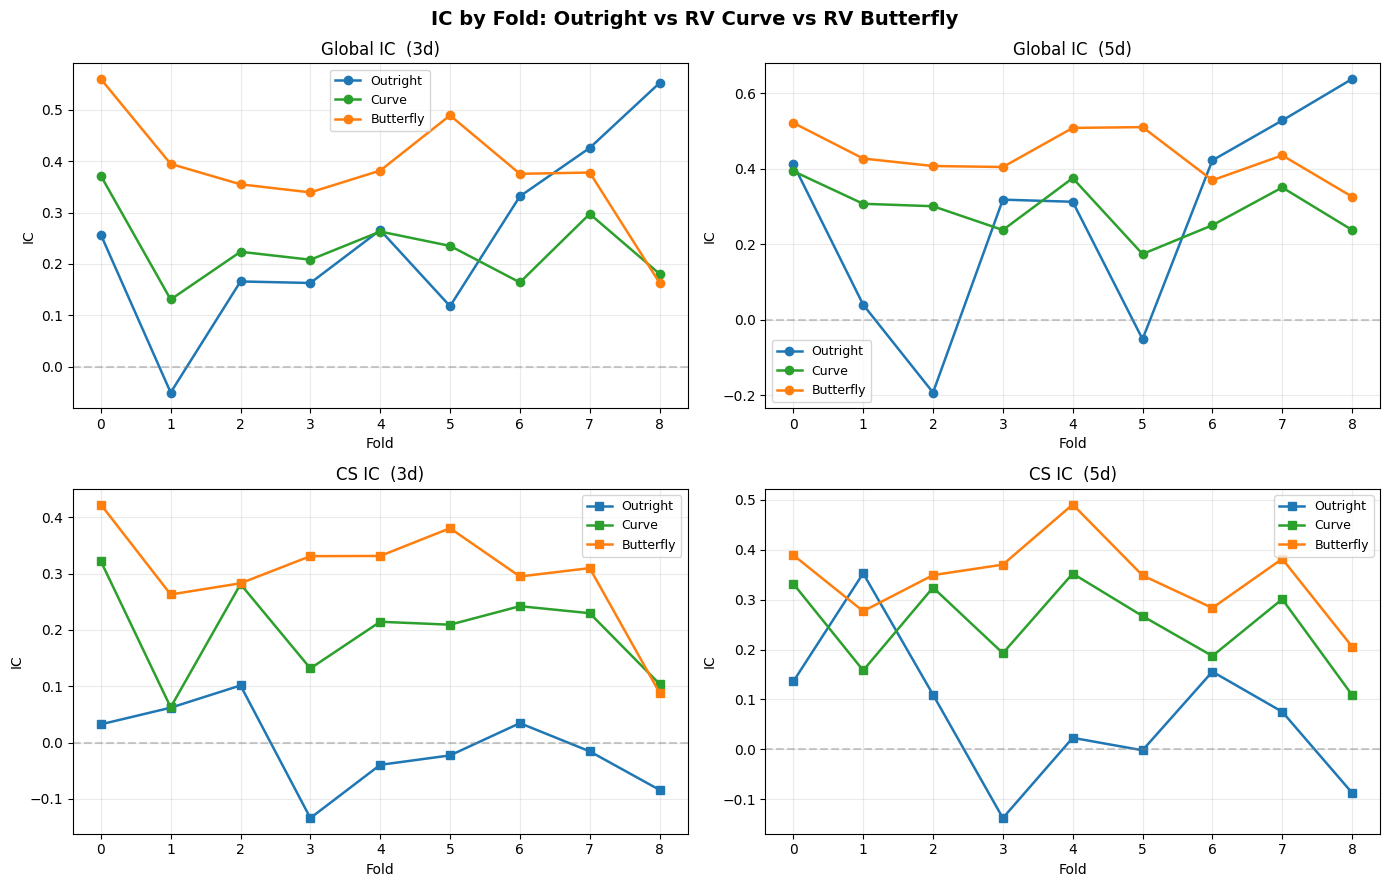

In [5]:
# ── Figure 1: フォールドごとの IC 比較 ──────────────────────────
# 上段: Global IC  下段: CS IC  左列: 3d  右列: 5d

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('IC by Fold: Outright vs RV Curve vs RV Butterfly', fontsize=14, fontweight='bold')

for col, h in enumerate(['3d', '5d']):
    for model in MODELS:
        key = f'{model}_{h}'
        r   = res[key]

        # Global IC per fold
        g_ics = fold_global_ic(r)
        folds = sorted(g_ics.keys())
        axes[0, col].plot(folds, [g_ics[f] for f in folds],
                          marker='o', label=model, color=COLORS[model], linewidth=1.8)

        # CS IC per fold
        c_ics = fold_cs_ic(r, CS_INDICES[model])
        axes[1, col].plot(folds, [c_ics.get(f, np.nan) for f in folds],
                          marker='s', label=model, color=COLORS[model], linewidth=1.8)

    for row in range(2):
        ax = axes[row, col]
        ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
        ax.set_xlabel('Fold')
        ax.set_ylabel('IC')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.25)
        ax.set_xticks(folds)

axes[0, 0].set_title('Global IC  (3d)')
axes[0, 1].set_title('Global IC  (5d)')
axes[1, 0].set_title('CS IC  (3d)')
axes[1, 1].set_title('CS IC  (5d)')

plt.tight_layout()
plt.savefig('../outputs/fig1_fold_ic.png', dpi=150, bbox_inches='tight')
plt.show()

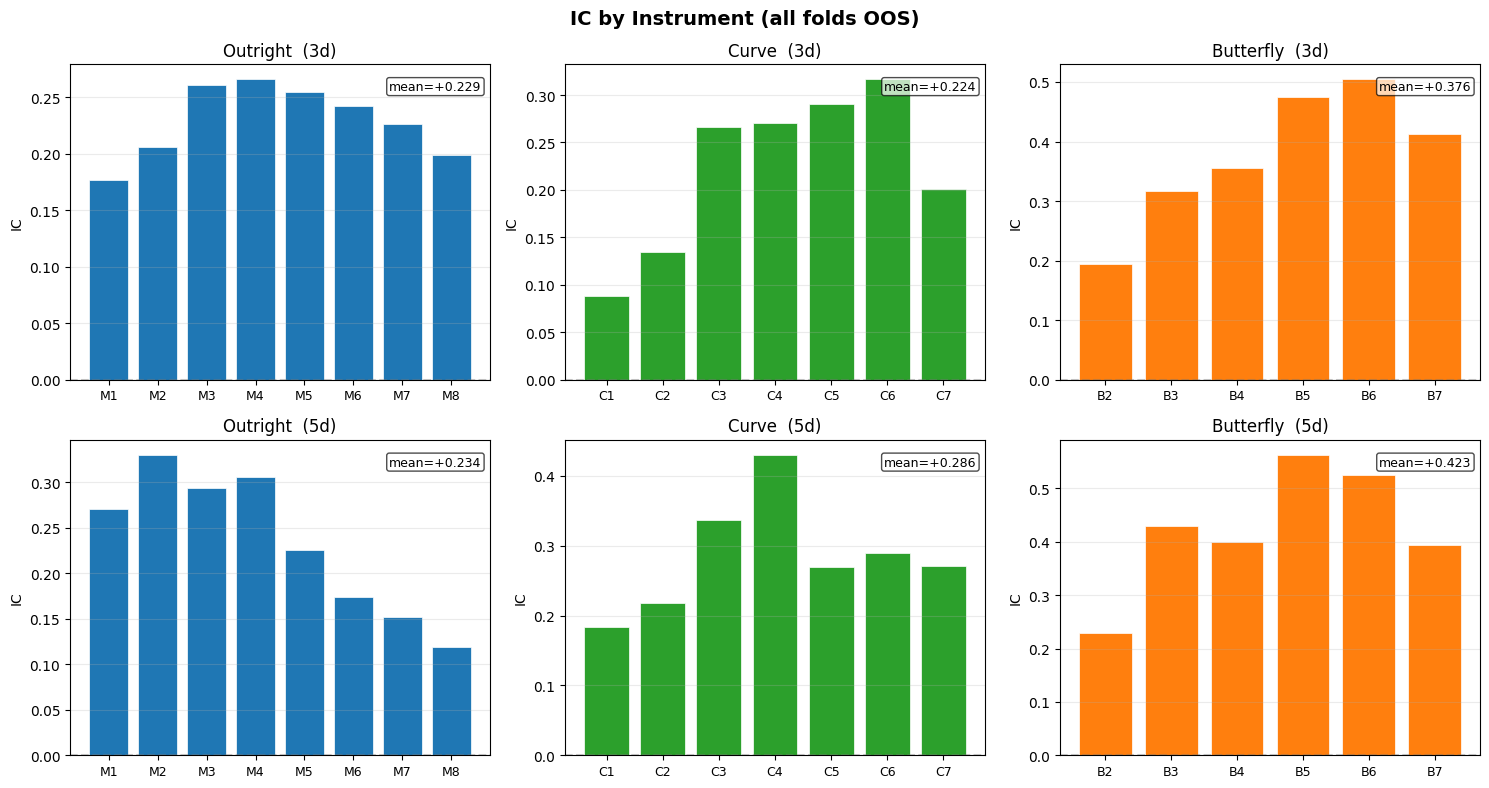

In [6]:
# ── Figure 2: 銘柄ごとの IC 比較 ────────────────────────────────
# 行: 3d / 5d   列: Outright / Curve / Butterfly

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('IC by Instrument (all folds OOS)', fontsize=14, fontweight='bold')

for row, h in enumerate(['3d', '5d']):
    for col, model in enumerate(MODELS):
        ax  = axes[row, col]
        key = f'{model}_{h}'
        r   = res[key]

        inst_ics = instrument_ic(r, CS_INDICES[model])
        insts    = sorted(inst_ics.keys())
        values   = [inst_ics.get(i, np.nan) for i in insts]
        bar_colors = [COLORS[model] if v >= 0 else '#d62728' for v in values]

        ax.bar(range(len(insts)), values, color=bar_colors, edgecolor='white', linewidth=0.5)
        ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
        ax.set_xticks(range(len(insts)))
        ax.set_xticklabels([INST_SHORT[model][i] for i in insts], fontsize=9)
        ax.set_ylabel('IC')
        ax.set_title(f'{model}  ({h})')
        ax.grid(True, axis='y', alpha=0.25)

        # 平均 IC を注記
        mean_ic = np.nanmean(values)
        ax.text(0.98, 0.95, f'mean={mean_ic:+.3f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig('../outputs/fig2_instrument_ic.png', dpi=150, bbox_inches='tight')
plt.show()

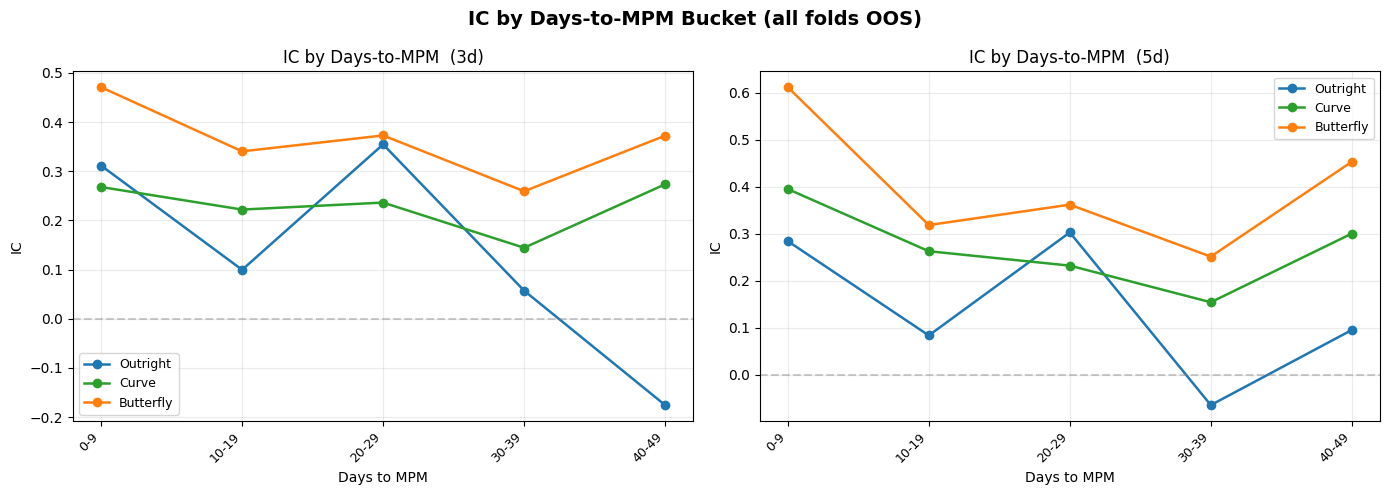

In [7]:
# ── Figure 3: Days_to_MPM バケットごとの IC ─────────────────────
# 左: 3d   右: 5d   3モデルを折れ線で比較

BIN_SIZE = 10
MAX_DAYS = 65

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('IC by Days-to-MPM Bucket (all folds OOS)', fontsize=14, fontweight='bold')

for col, h in enumerate(['3d', '5d']):
    ax = axes[col]
    for model in MODELS:
        key  = f'{model}_{h}'
        r    = res[key]
        d_ic = days_bucket_ic(r, instrument_indices=CS_INDICES[model],
                              bin_size=BIN_SIZE, max_days=MAX_DAYS)
        buckets = list(d_ic.keys())
        values  = list(d_ic.values())
        ax.plot(range(len(buckets)), values, marker='o',
                label=model, color=COLORS[model], linewidth=1.8)

    ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
    ax.set_xticks(range(len(buckets)))
    ax.set_xticklabels(buckets, rotation=45, ha='right', fontsize=9)
    ax.set_xlabel('Days to MPM')
    ax.set_ylabel('IC')
    ax.set_title(f'IC by Days-to-MPM  ({h})')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('../outputs/fig3_days_to_mpm_ic.png', dpi=150, bbox_inches='tight')
plt.show()

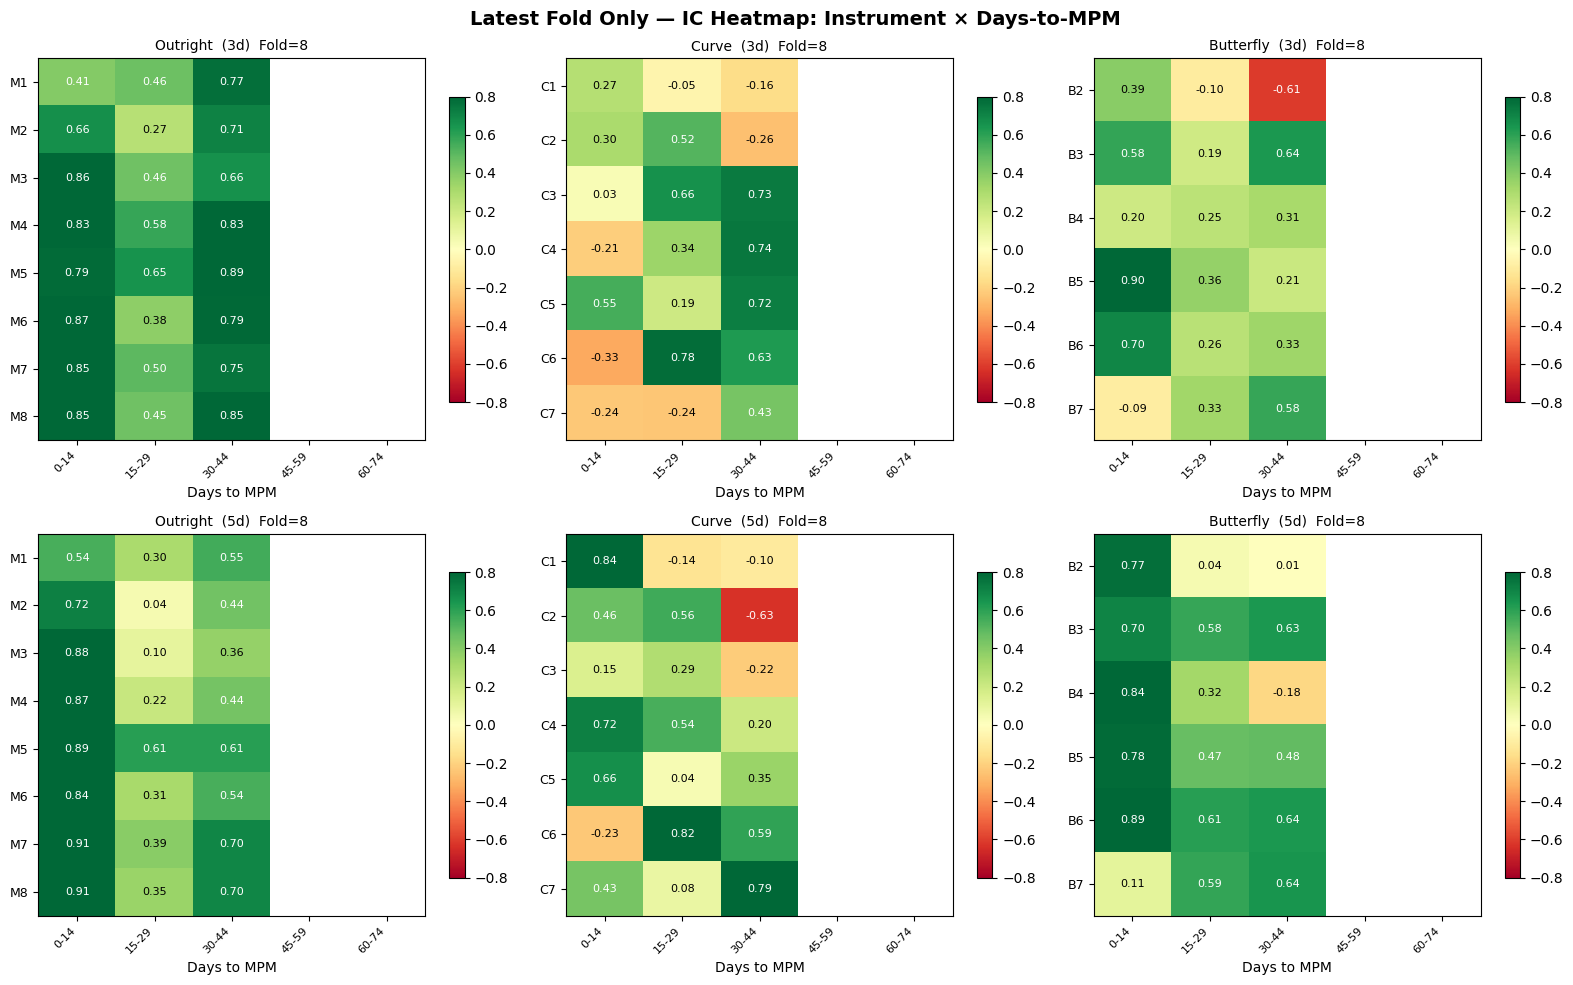

In [8]:
# ── Figure 4: 最新フォールドのみ ── 銘柄 × Days_to_MPM ヒートマップ ─
# 上段: 3d  下段: 5d  横3列: Outright / Curve / Butterfly

BIN_SIZE = 15   # 最新フォールドはサンプルが少ないため幅を広げる
MAX_DAYS = 65
MIN_N    = 3

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Latest Fold Only — IC Heatmap: Instrument × Days-to-MPM',
             fontsize=14, fontweight='bold')

vmax = 0.8   # カラースケールの絶対値上限（全パネル共通）
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
cmap = plt.cm.RdYlGn

for row, h in enumerate(['3d', '5d']):
    for col, model in enumerate(MODELS):
        ax  = axes[row, col]
        key = f'{model}_{h}'
        r   = res[key]

        # 最新フォールドのみに絞る
        latest_fold = int(r['Fold'].max())
        r_latest    = r[r['Fold'] == latest_fold].copy()

        mat = heatmap_data(r_latest, CS_INDICES[model],
                           bin_size=BIN_SIZE, max_days=MAX_DAYS, min_n=MIN_N)

        im = ax.imshow(mat.values.astype(float), aspect='auto',
                       cmap=cmap, norm=norm)

        # 数値を各セルに表示
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                v = mat.iloc[i, j]
                if not np.isnan(v):
                    ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                            fontsize=8, color='black' if abs(v) < 0.4 else 'white')

        ax.set_xticks(range(len(mat.columns)))
        ax.set_xticklabels(mat.columns, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(mat.index)))
        ax.set_yticklabels([INST_SHORT[model][i] for i in mat.index], fontsize=9)
        ax.set_xlabel('Days to MPM')
        ax.set_title(f'{model}  ({h})  Fold={latest_fold}', fontsize=10)

        plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig('../outputs/fig4_latest_fold_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

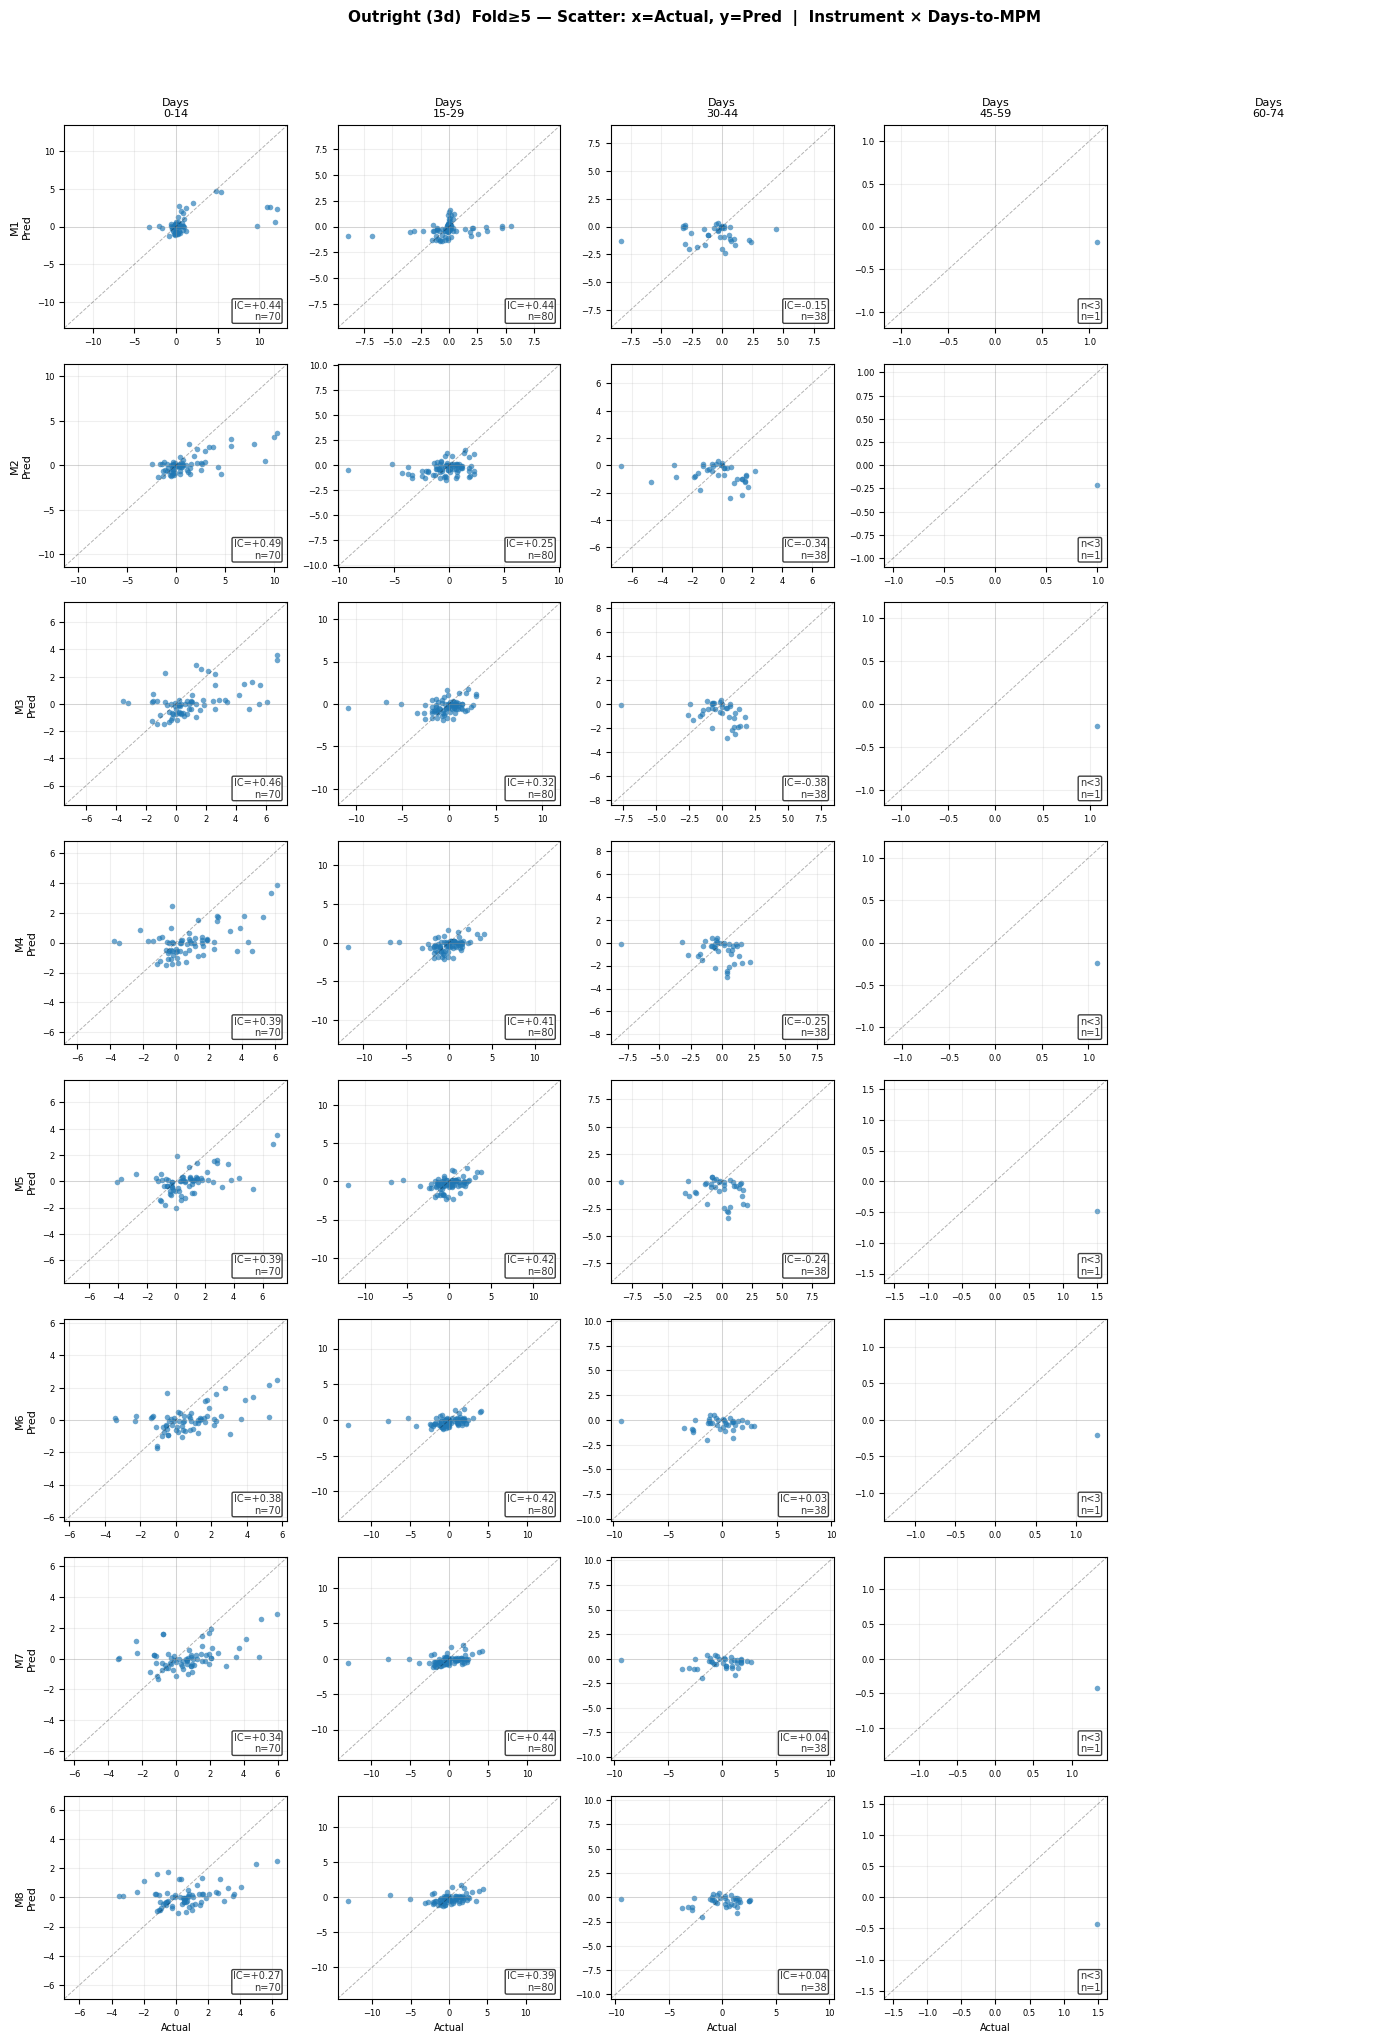

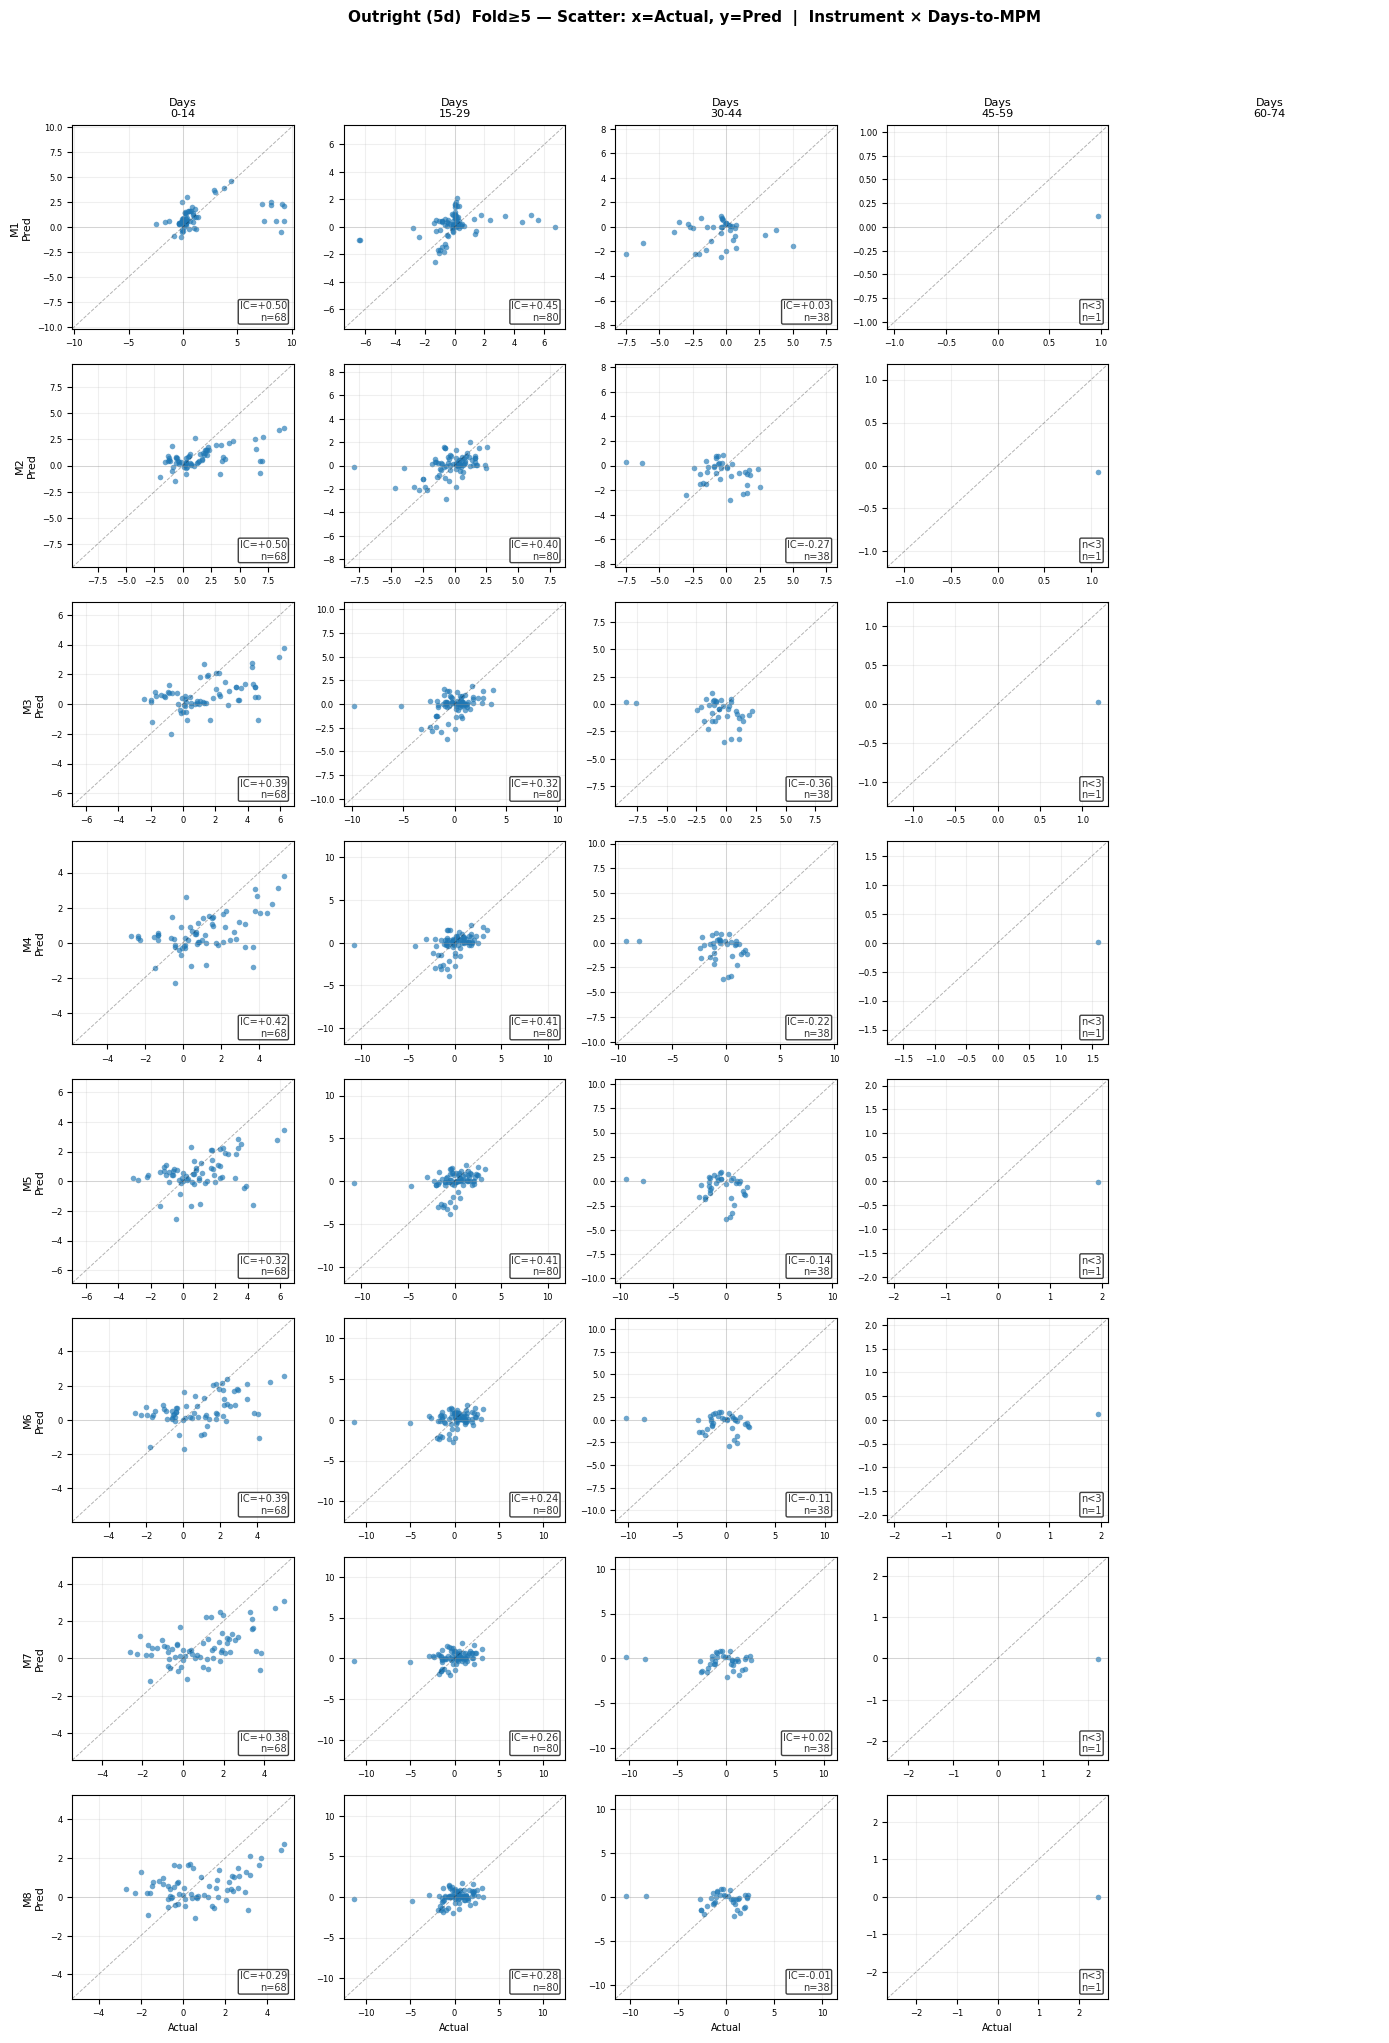

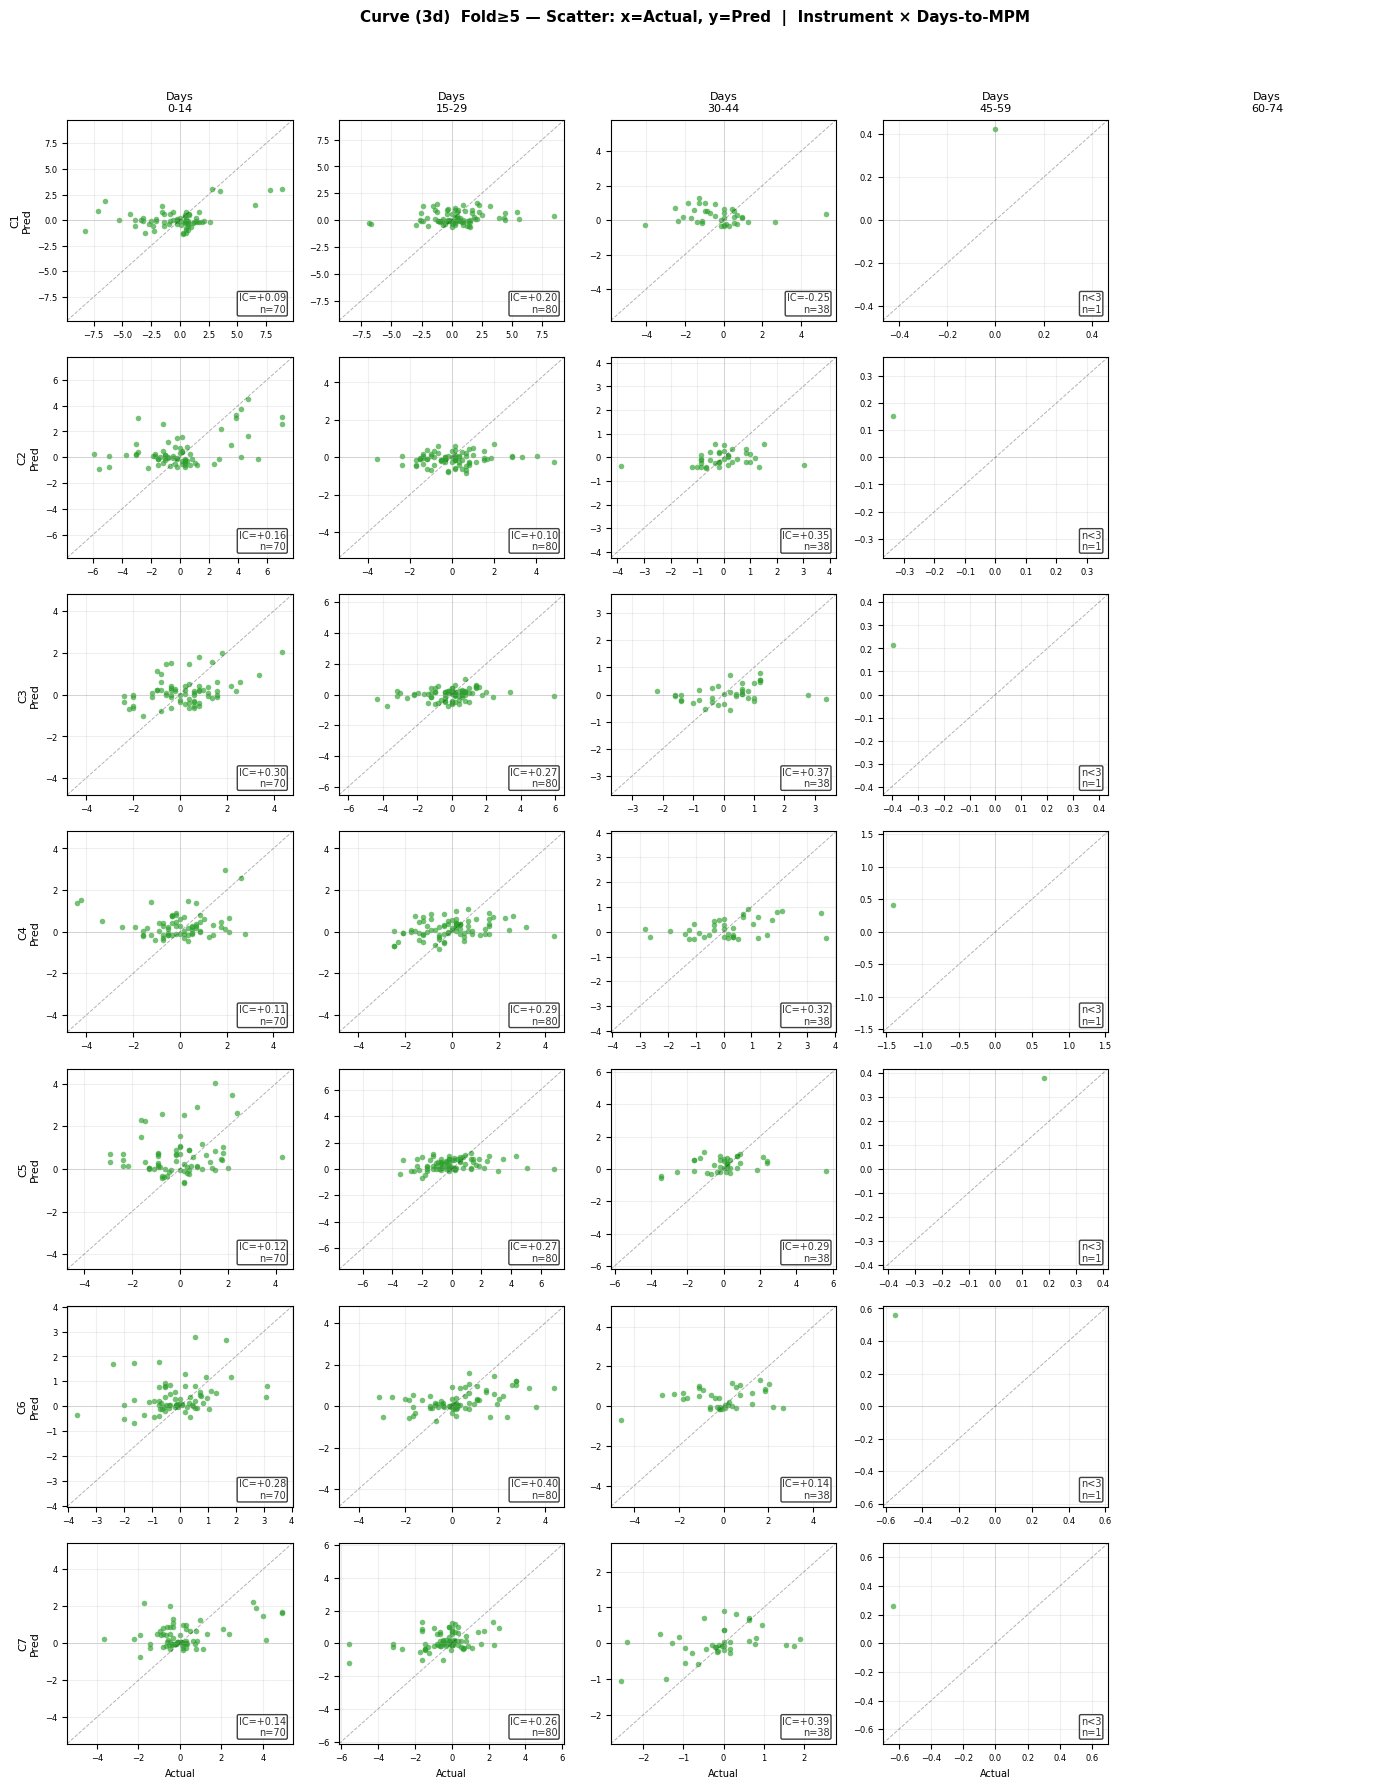

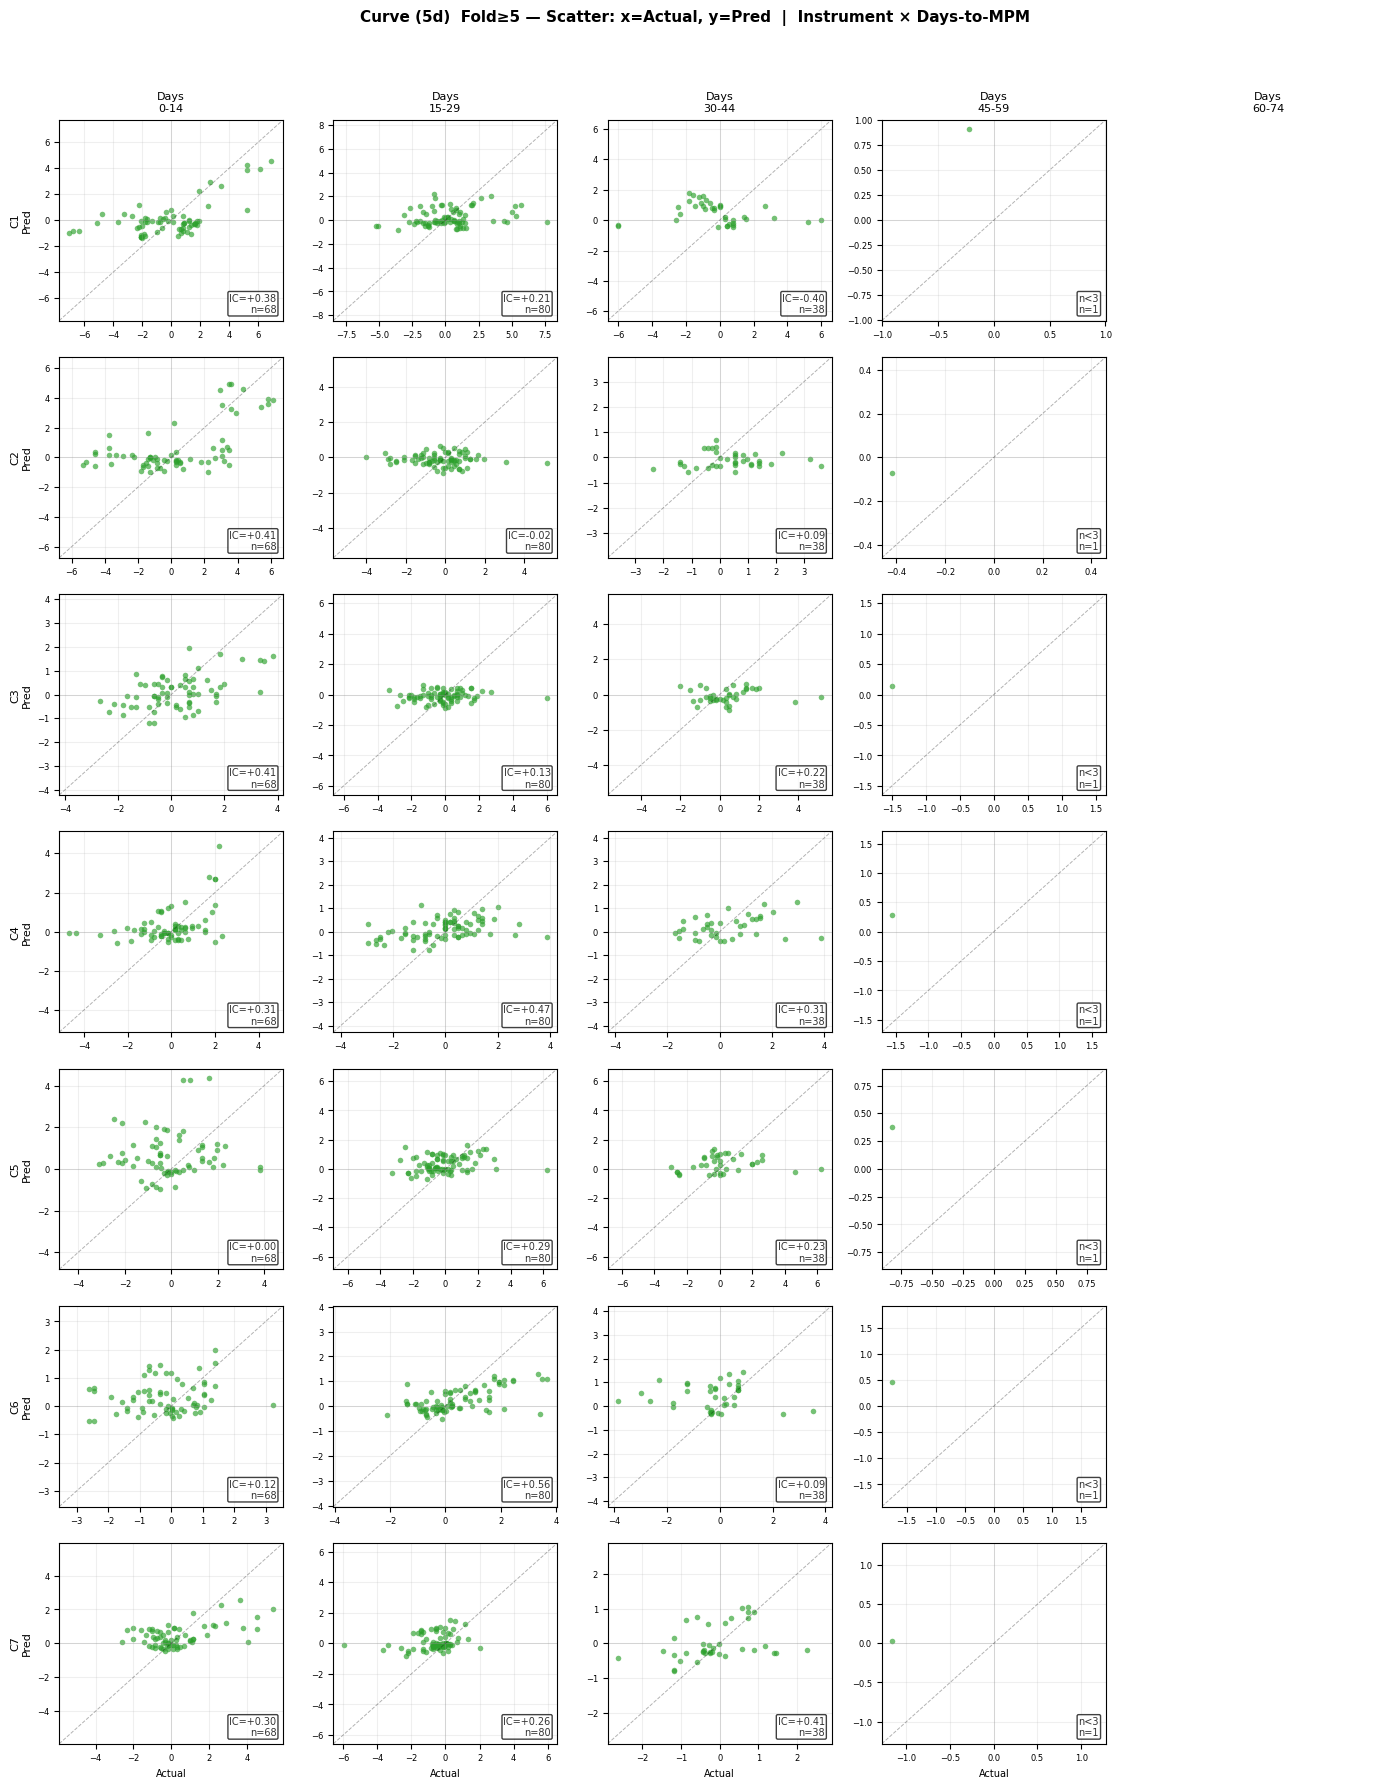

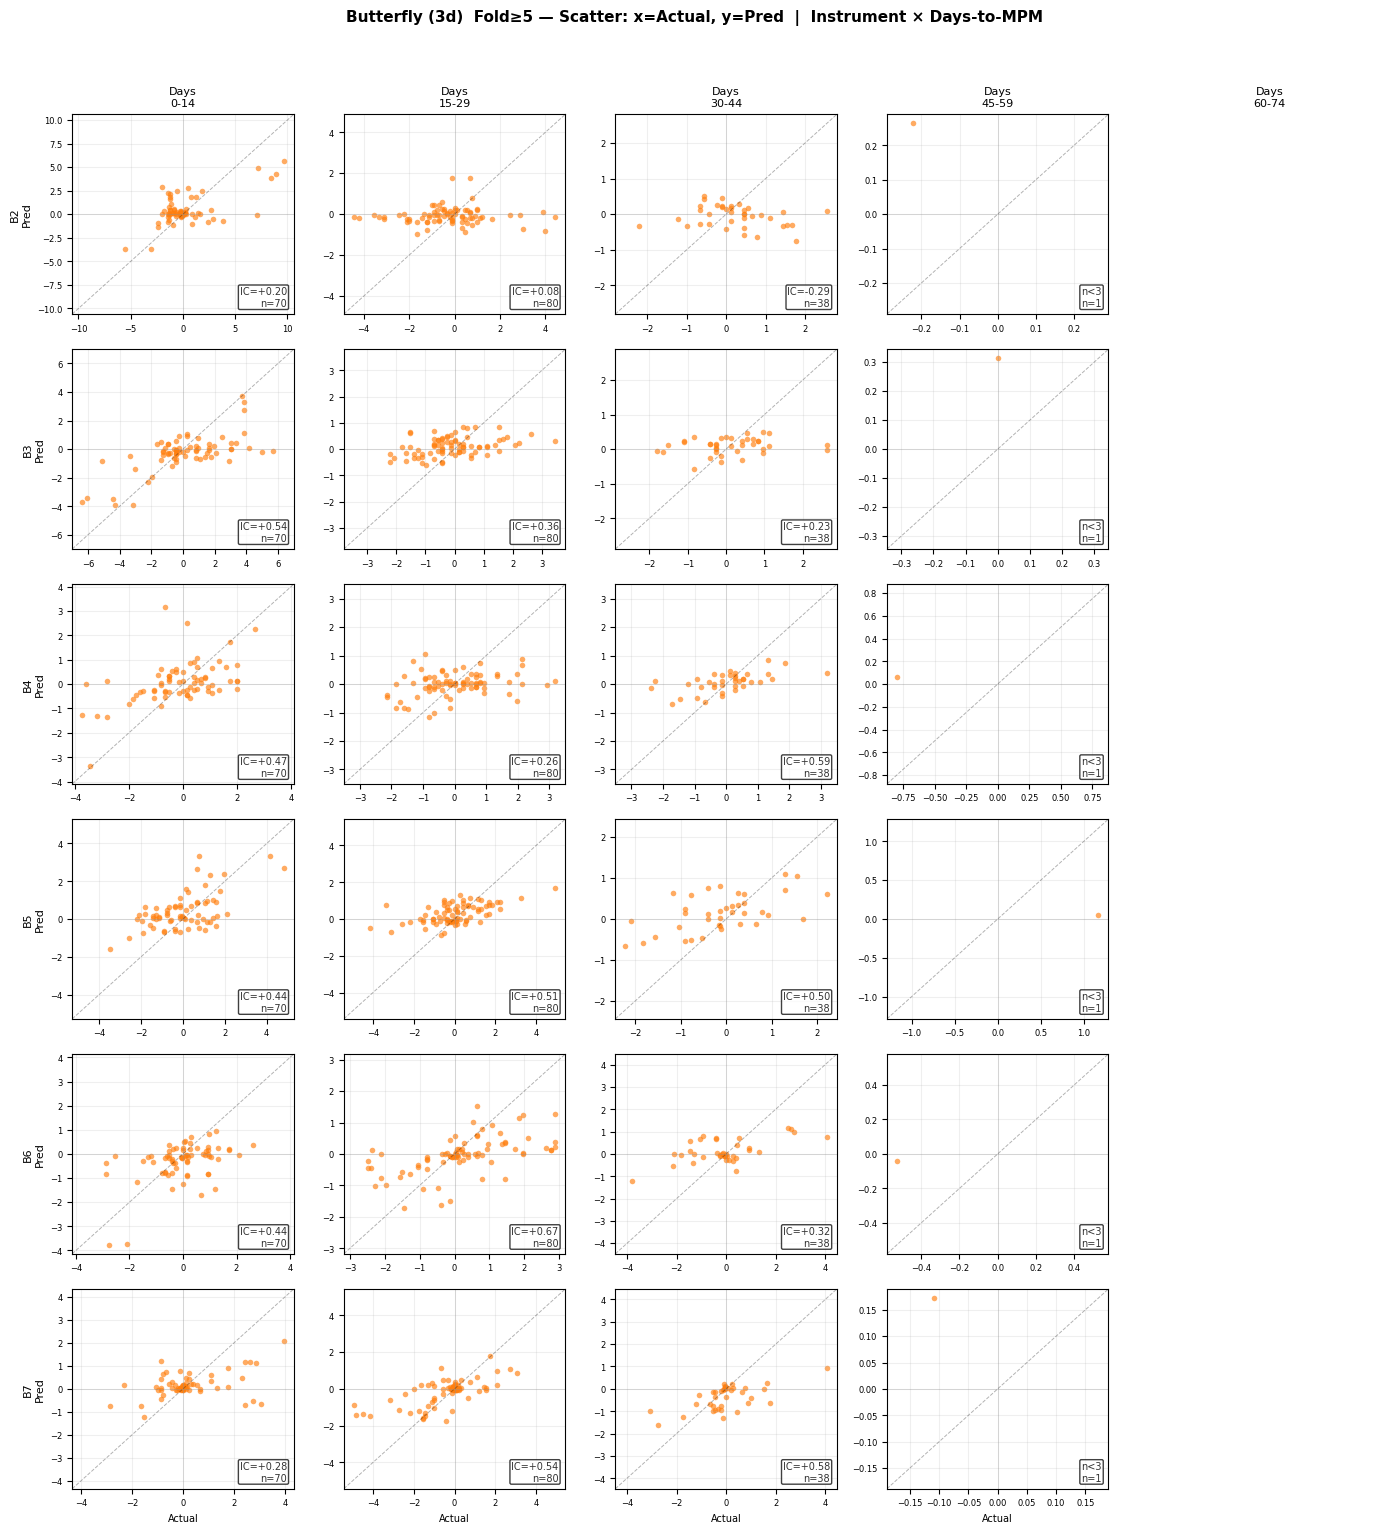

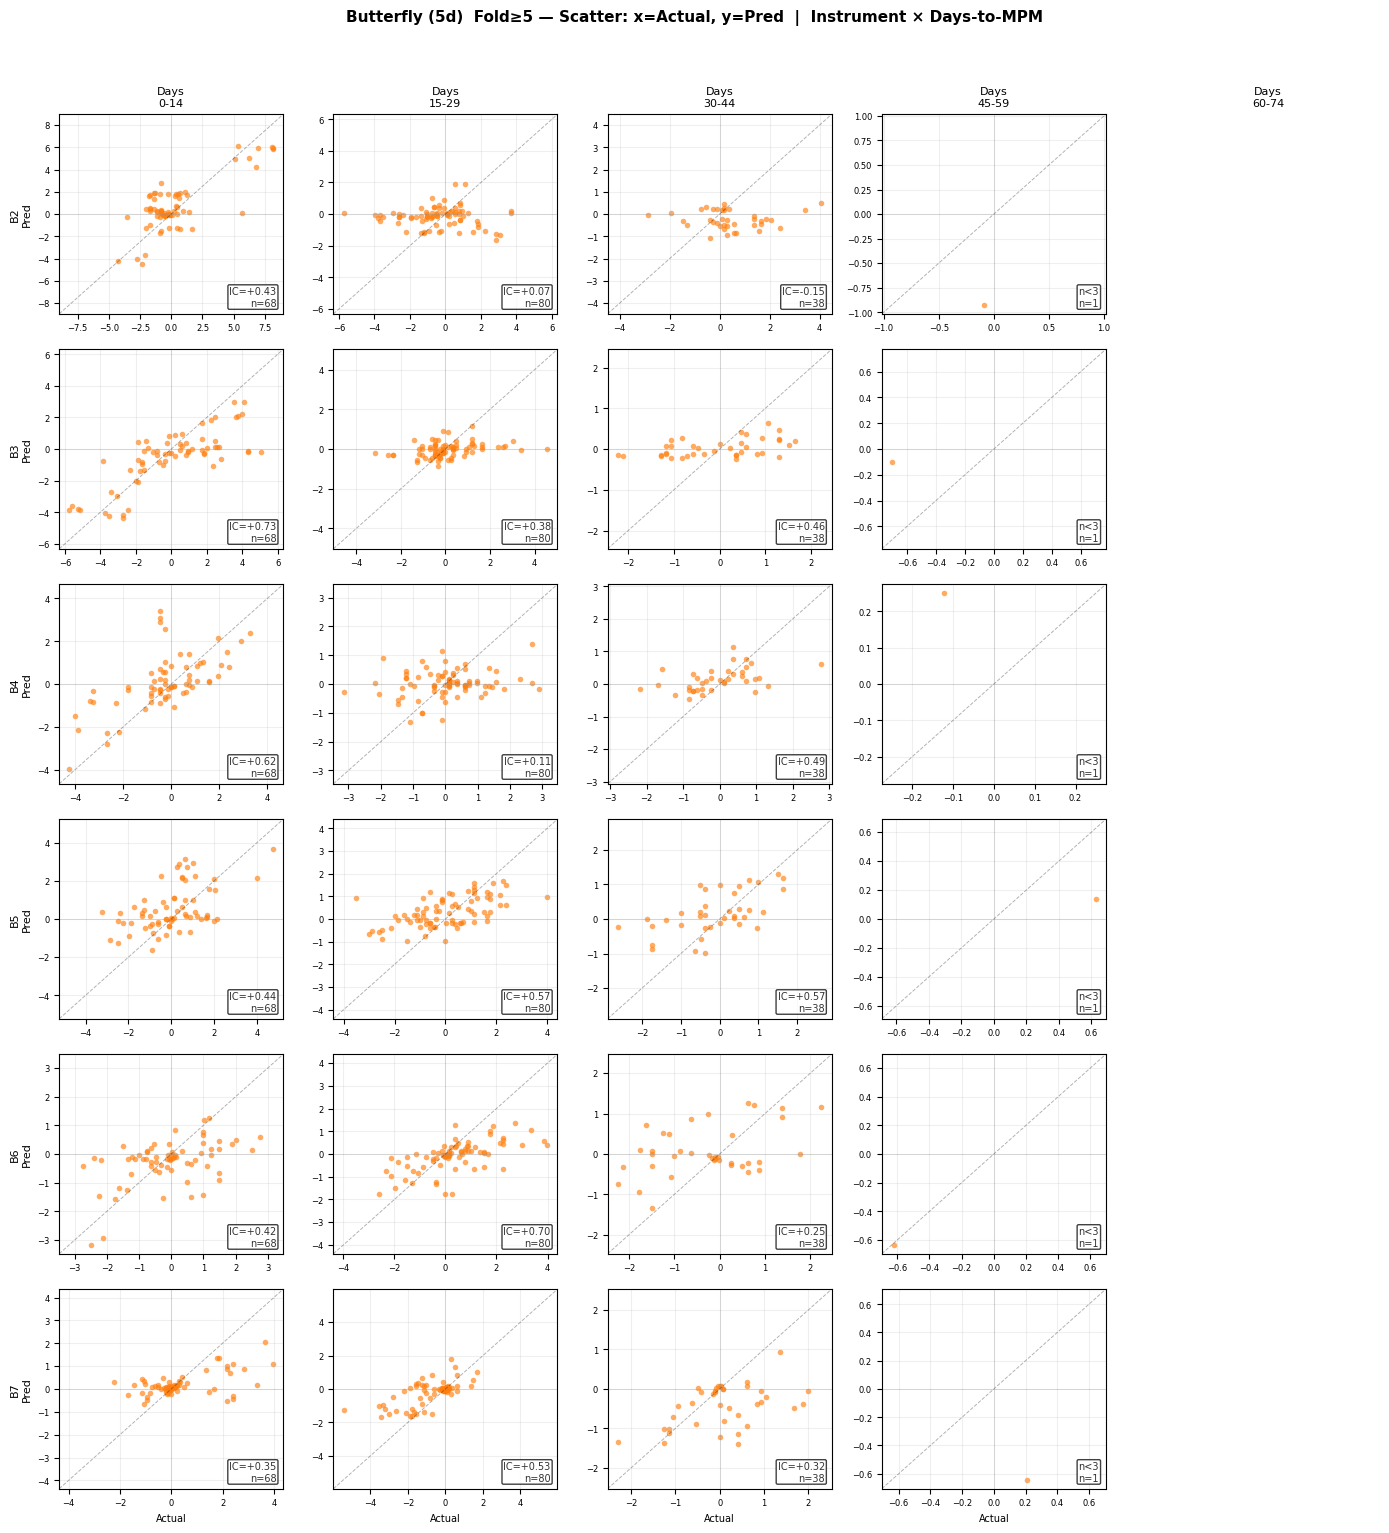

In [9]:
# ── Figure 6/7/8: Fold5以降 ── 散布図グリッド（銘柄 × Days_to_MPM）─
# x軸 = Actual（実測値）、y軸 = Pred（予測値）
# 3モデル × 3d・5d = 6枚出力

SCATTER_FOLD_MIN = 5   # Fold5以降を使用
BIN_SIZE_SC      = 15
MAX_DAYS_SC      = 65

def scatter_grid(results, instrument_indices, inst_short_map, model_color,
                 bin_size=15, max_days=65, h_label='3d', model_label='',
                 fold_min=5, fig_path=None):
    """
    銘柄 × Days_bucket の散布図グリッドを描画する。
    x軸 = Actual（実測値）、y軸 = Pred（予測値）
    各セルに IC と n を注記。データが少ないセルは「少」と表示。
    """
    df = results[
        (results['Meeting_Index'].isin(instrument_indices)) &
        (results['Fold'] >= fold_min)
    ].copy()

    bins   = list(range(0, max_days + bin_size, bin_size))
    labels = [f'{b}-{b+bin_size-1}' for b in bins[:-1]]
    df['bucket'] = pd.cut(df['Days_to_MPM'], bins=bins, labels=labels, right=False)

    insts  = sorted(instrument_indices)
    n_rows = len(insts)
    n_cols = len(labels)

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 2.8, n_rows * 2.6),
                             squeeze=False)
    fig.suptitle(
        f'{model_label} ({h_label})  Fold≥{fold_min} — '
        f'Scatter: x=Actual, y=Pred  |  Instrument × Days-to-MPM',
        fontsize=11, fontweight='bold'
    )

    for ri, inst in enumerate(insts):
        for ci, bucket in enumerate(labels):
            ax  = axes[ri, ci]
            sub = df[(df['Meeting_Index'] == inst) & (df['bucket'] == bucket)]

            # 行ラベル（左端のみ）・列ラベル（上段のみ）
            if ci == 0:
                ax.set_ylabel(inst_short_map[inst], fontsize=9, labelpad=4)
            if ri == 0:
                ax.set_title(f'Days\n{bucket}', fontsize=8)
            # 最下段のみ x軸ラベル
            if ri == n_rows - 1:
                ax.set_xlabel('Actual', fontsize=7)
            # 左端のみ y軸ラベル追記
            if ci == 0:
                ax.set_ylabel(f'{inst_short_map[inst]}\nPred', fontsize=8)

            if len(sub) == 0:
                ax.axis('off')
                continue

            ax.scatter(sub['Actual'], sub['Pred'],
                       color=model_color, alpha=0.65, s=16, linewidths=0)
            ax.axhline(0, color='gray', linewidth=0.5, alpha=0.35)
            ax.axvline(0, color='gray', linewidth=0.5, alpha=0.35)

            # 45度線（理想予測ライン）
            lim_val = max(sub['Actual'].abs().max(), sub['Pred'].abs().max()) * 1.1
            if lim_val > 0:
                ax.plot([-lim_val, lim_val], [-lim_val, lim_val],
                        color='black', linewidth=0.7, linestyle='--', alpha=0.3)
                ax.set_xlim(-lim_val, lim_val)
                ax.set_ylim(-lim_val, lim_val)

            # IC と n を右下に注記
            n = len(sub)
            if n >= 3:
                ic_val, _ = spearmanr(sub['Actual'], sub['Pred'])
                ic_str = f'IC={ic_val:+.2f}' if not np.isnan(ic_val) else 'IC=nan'
            else:
                ic_str = 'n<3'
            ax.text(0.97, 0.03, f'{ic_str}\nn={n}',
                    transform=ax.transAxes, ha='right', va='bottom',
                    fontsize=7, color='#333333',
                    bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.75))

            ax.tick_params(labelsize=6)
            ax.grid(True, alpha=0.2)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    if fig_path:
        plt.savefig(fig_path, dpi=130, bbox_inches='tight')
    plt.show()


# 3モデル × 2ホライズン = 6枚
for model in MODELS:
    for h in ['3d', '5d']:
        key = f'{model}_{h}'
        scatter_grid(
            results            = res[key],
            instrument_indices = CS_INDICES[model],
            inst_short_map     = INST_SHORT[model],
            model_color        = COLORS[model],
            bin_size           = BIN_SIZE_SC,
            max_days           = MAX_DAYS_SC,
            h_label            = h,
            model_label        = model,
            fold_min           = SCATTER_FOLD_MIN,
            fig_path           = f'../outputs/fig6_scatter_{model.lower()}_{h}.png',
        )


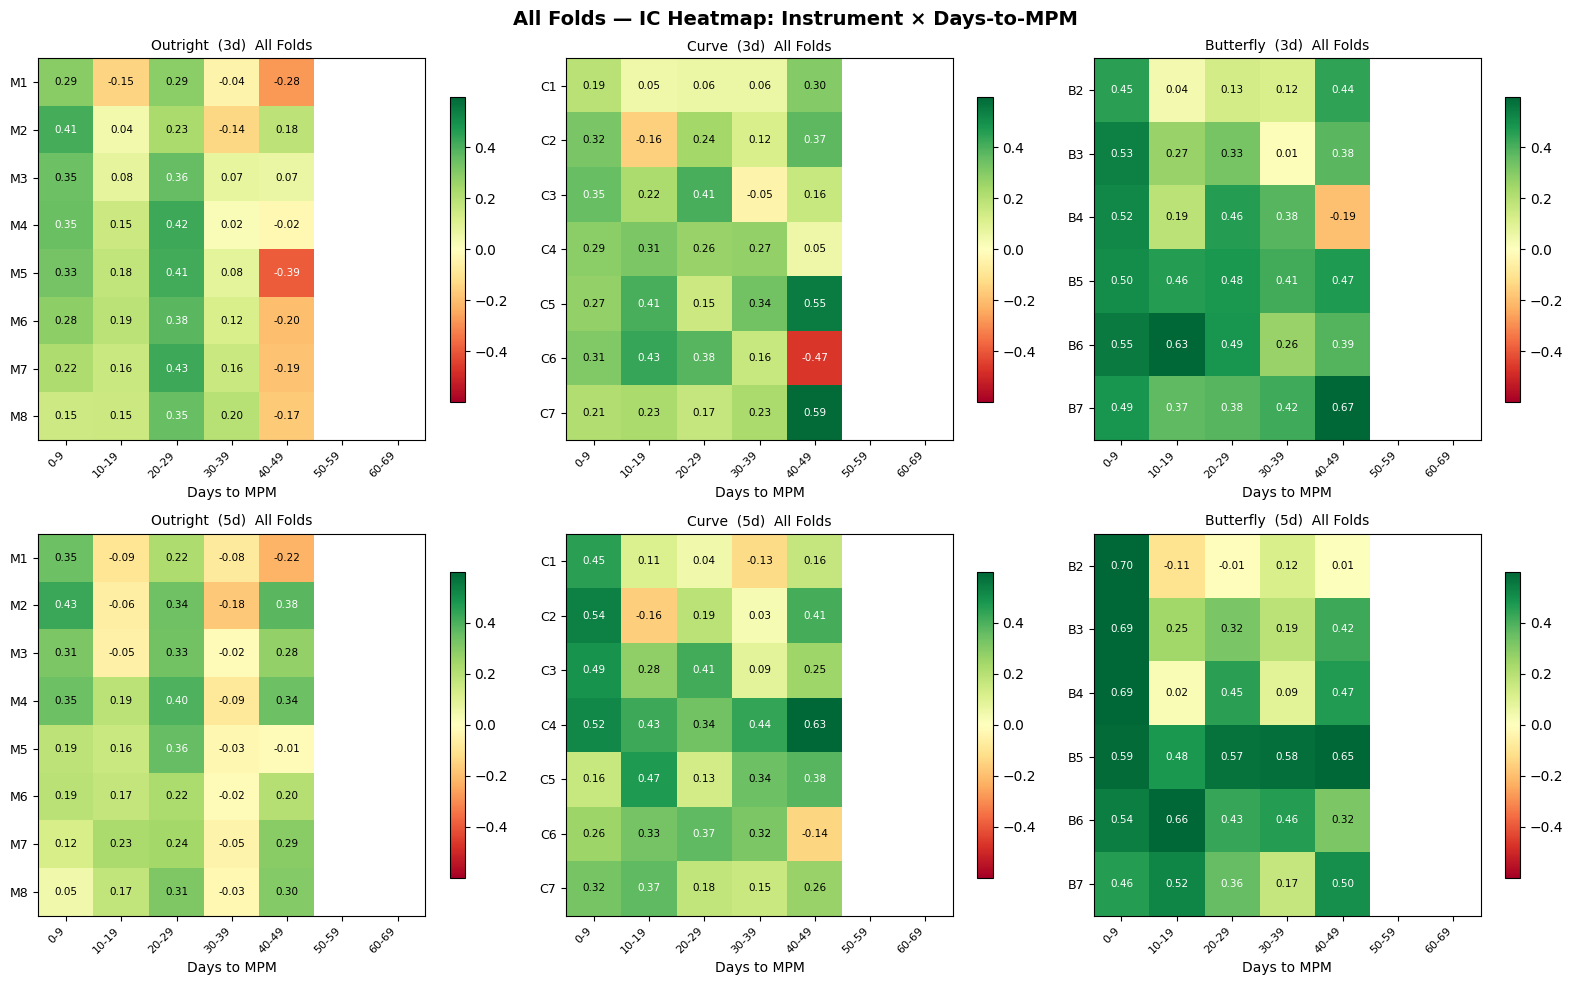

In [10]:
# ── Figure 5: 全フォールド集計 ── 銘柄 × Days_to_MPM ヒートマップ ─
# Figure 4 の全フォールド版（参照用）

BIN_SIZE_ALL = 10
MIN_N_ALL    = 10

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('All Folds — IC Heatmap: Instrument × Days-to-MPM',
             fontsize=14, fontweight='bold')

norm2 = TwoSlopeNorm(vmin=-0.6, vcenter=0, vmax=0.6)

for row, h in enumerate(['3d', '5d']):
    for col, model in enumerate(MODELS):
        ax  = axes[row, col]
        key = f'{model}_{h}'
        r   = res[key]

        mat = heatmap_data(r, CS_INDICES[model],
                           bin_size=BIN_SIZE_ALL, max_days=MAX_DAYS, min_n=MIN_N_ALL)

        im = ax.imshow(mat.values.astype(float), aspect='auto',
                       cmap=cmap, norm=norm2)

        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                v = mat.iloc[i, j]
                if not np.isnan(v):
                    ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                            fontsize=7.5, color='black' if abs(v) < 0.35 else 'white')

        ax.set_xticks(range(len(mat.columns)))
        ax.set_xticklabels(mat.columns, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(mat.index)))
        ax.set_yticklabels([INST_SHORT[model][i] for i in mat.index], fontsize=9)
        ax.set_xlabel('Days to MPM')
        ax.set_title(f'{model}  ({h})  All Folds', fontsize=10)
        plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig('../outputs/fig5_all_folds_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ── サマリーテーブル ─────────────────────────────────────────────
rows = []
for model in MODELS:
    for h in ['3d', '5d']:
        key = f'{model}_{h}'
        ic  = summarize_ic(res[key], instrument_indices=CS_INDICES[model])
        rows.append({
            'Model':    model,
            'Horizon':  h,
            'Global IC': round(ic['ic_all'],   4),
            'CS IC':     round(ic['cs_ic'],    4),
            'TS IC':     round(ic['ts_ic'],    4),
            'Train IC':  round(ic['train_ic'], 4),
            'Gap':       round(ic['gap'],      4),
            'Recent 3F': round(ic['ic_recent'],4),
        })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

    Model Horizon  Global IC   CS IC  TS IC  Train IC    Gap  Recent 3F
 Outright      3d     0.2267 -0.0051 0.2293    0.5186 0.2919     0.4242
 Outright      5d     0.2280  0.0743 0.2340    0.5640 0.3360     0.4499
    Curve      3d     0.2223  0.2016 0.2240    0.4686 0.2463     0.2145
    Curve      5d     0.2779  0.2495 0.2856    0.5254 0.2476     0.3000
Butterfly      3d     0.3732  0.3045 0.3763    0.5211 0.1479     0.3215
Butterfly      5d     0.4185  0.3459 0.4232    0.5729 0.1544     0.3812
